In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten 
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
from scipy.optimize import curve_fit
plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

In [2]:
def snr_mf(A,T,sigma):
    delta = A**2/T
    return ((np.pi)**3)/(2*(np.pi + 4))*(delta)/(sigma**2)

In [3]:
np.random.seed(12345)
jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]

In [20]:
def snr_tot(A1, T1, sigma1, A2, T2, sigma2):
    snr_1 = snr_mf(A1, T1, sigma1)
    snr_2 = snr_mf(A2, T2, sigma2)
    
    den = (A1/sigma1)*(A2/sigma2)

    if den == 0:
        return 0
    
    return ((A1/sigma1)*snr_1 + (A2/sigma2)*snr_2)/((A1/sigma1)*(A2/sigma2))

In [7]:
def pattern(i,z,a):
    return [int(a*np.cos((np.pi*i)/z)), int(a*np.sin((np.pi*i)/z))]

In [8]:
#Generation of 8 datasets with different amplitudes
Z=12

N=10000
L=60

DX1 = 50 
bias1 = 5 
DX2 = 20
bias2 = 10

y = np.zeros(N) # 1D (same label)
x = np.zeros((N,L,2))

for A in range(0, 350, 50):
    str0 = f'ts_L{L}_Z{Z}_A{A}_DX({DX1,DX2})_bias({bias1,bias2})_N{N}'
    print(str0)
    
    for i in range(N):
        if i>0: 
            jump0, jump1 = jump(bias1, bias2, DX1, DX2)
            x[i][0][0] = x[i-1][-1][0] + jump0 
            x[i][0][1] = x[i-1][-1][1] + jump1
        
        for j in range(1,L):
            jump0, jump1 = jump(bias1, bias2, DX1, DX2)
            x[i][j][0] = x[i][j-1][0] + jump0
            x[i][j][1] = x[i][j-1][1] + jump1
            
        y[i] = i%3 # assign class labels (0,1,2)
               
        if y[i]>0:
            j0 = np.random.randint(0,L-1-Z) 
            sign = 3-2*y[i] 
            for j in range(Z): 
                x[i][j0+j][0] += sign*pattern(j,Z,A)[0]
                x[i][j0+j][1] += sign*pattern(j,Z,A)[1]

    fname='x'+str0
    np.save(fname,x)
    fname='y'+str0
    np.save(fname,y)

ts_L60_Z12_A0_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A50_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A100_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A150_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A200_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A250_DX((50, 20))_bias((5, 10))_N10000
ts_L60_Z12_A300_DX((50, 20))_bias((5, 10))_N10000


In [15]:
n_class=3
NF=5
l2_reg=0.2
stddev=0.05

In [9]:
def build_model(L, n_class=3, NF=5, l2_reg=0.2, stddev=0.05):
    
    input_shape = (L, 2)
    
    reg = tf.keras.regularizers.l2(l2_reg)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=stddev, seed=None)
    
    model = Sequential([
        Conv1D(filters=NF, kernel_size=11,
               kernel_initializer=ini,
               kernel_regularizer=reg,
               activation='relu',
               input_shape=input_shape),
        AveragePooling1D(5),
        Conv1D(filters=5, kernel_size=7, activation='relu'),
        Flatten(),
        Dense(12, activation='relu'),
        Dropout(0.2),
        Dense(n_class, activation='softmax')
    ])
    
    model.compile(
        loss=keras.losses.categorical_crossentropy,
        optimizer=tf.keras.optimizers.Adam(),
        metrics=['accuracy']
    )
    
    return model

In [16]:
#training the cnn over different datasets
BATCH_SIZE = 200
EPOCHS = 10
best_acc = 0
j = 0
models = []
acc = []

for A in range(0,350,50):
    model = build_model(60)
    str0 = f'ts_L{L}_Z{Z}_A{A}_DX({DX1,DX2})_bias({bias1,bias2})_N{N}.npy'
    fnamex='x'+str0
    fnamey='y'+str0
    
    x = np.load(fnamex)
    
    N,L = len(x), len(x[0])

    categ = np.load(fnamey)
    
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][int(categ[i])] = 1. # y contains one-hot encoding


    # split into training and validation sets
    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    
    # rescale with variance on the training set
    for i in range(N_train):
         x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
    
    x_train = x_train.reshape(x_train.shape[0], L, 2)
    x_val =  x_val.reshape(x_val.shape[0], L, 2)

    fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=0, shuffle=True) 
    
    models.append(fit)    
    acc.append(fit.history['val_accuracy'][-1])
    
    if fit.history['val_accuracy'][-1] > best_acc:
        best_acc = fit.history['val_accuracy'][-1]
        best_model = fit
        best_A = A

    print(f"Training dataset: {j}")
    j+=1

Training dataset: 0
Training dataset: 1
Training dataset: 2
Training dataset: 3
Training dataset: 4
Training dataset: 5
Training dataset: 6


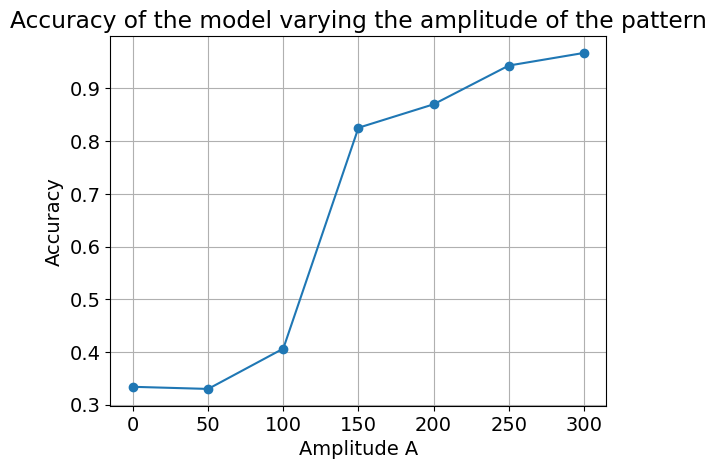

In [18]:
plt.plot(np.arange(0, 350, 50), acc, marker='o')
plt.xlabel("Amplitude A")
plt.ylabel("Accuracy")
plt.title("Accuracy of the model varying the amplitude of the pattern")
plt.grid()
plt.show()

In [21]:
SNR_mf1 = []
SNR_mf2 = []
SNR = []
for A in range(0,350,50):
    SNR_mf1.append(snr_mf(A,Z,DX1))
    SNR_mf2.append(snr_mf(A,Z,DX2))
    SNR.append(snr_tot(A, Z, DX1, A, Z, DX2))

In [22]:
for x, y in zip(SNR, acc):
    print(x, y)

0 0.33399999141693115
1.202998114505251 0.33000001311302185
2.405996229010502 0.4065000116825104
3.6089943435157537 0.8255000114440918
4.811992458021004 0.8700000047683716
6.014990572526254 0.9434999823570251
7.217988687031507 0.9674999713897705


In [24]:
print(list(zip(SNR, acc)))

[(0, 0.33399999141693115), (1.202998114505251, 0.33000001311302185), (2.405996229010502, 0.4065000116825104), (3.6089943435157537, 0.8255000114440918), (4.811992458021004, 0.8700000047683716), (6.014990572526254, 0.9434999823570251), (7.217988687031507, 0.9674999713897705)]


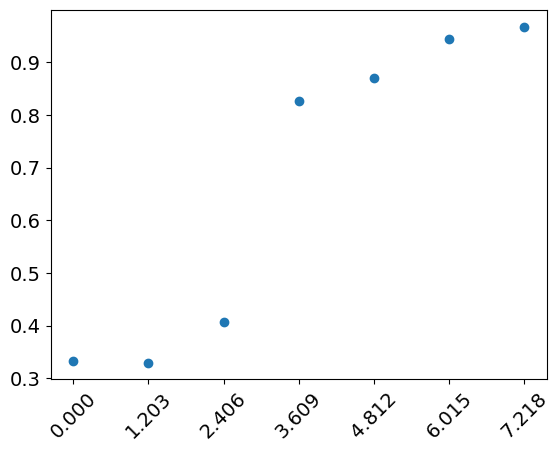

In [26]:
plt.scatter(SNR, acc)
plt.xticks(SNR, rotation=45) 

plt.show()

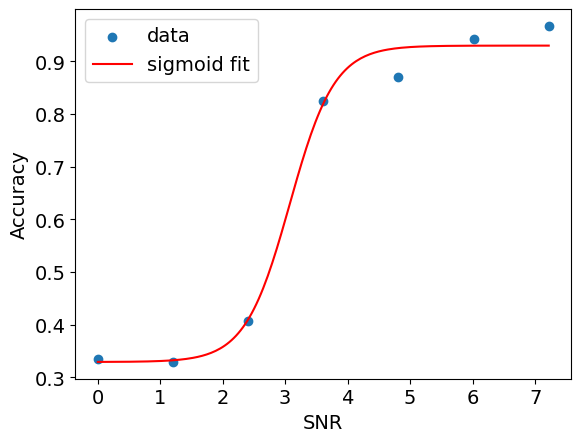

In [35]:
def sigmoid(x, L, x0, k, b):
    return L / (1 + np.exp(-k*(x-x0))) + b

xdata = np.array(SNR)
ydata = np.array(acc)

p0 = [1, np.median(xdata), 1, 0]

popt, pcov = curve_fit(sigmoid, xdata, ydata, p0)

xfit = np.linspace(min(xdata), max(xdata), 200)
yfit = sigmoid(xfit, *popt)

plt.scatter(xdata, ydata, label='data')
plt.plot(xfit, yfit, label='sigmoid fit', color = 'r')
plt.xlabel('SNR')
plt.ylabel('Accuracy')
plt.legend()
plt.show()